# Machine Learning - ARX Model

$$y(k) + a_1y(k-1) + \dots + a_ny(k-n) = b_0u(k-d)+ \dots + b_mu(k-d-m) + e(k)$$

Where 

$\bullet$ $k$ : discrete time $[0,N-1]$

$\bullet$ $y$ : output sequence

$\bullet$  $u \in R^{N}$ : input sequence 

$\bullet $   $e$ : noise sequence

$\bullet $   $n\geq 0, m\geq 0, d\geq 0$ : model order parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Data importation

In [2]:
# Data importation
u_test = np.load('u_test.npy')
u_train = np.load('u_train.npy')
output_train = np.load('output_train.npy')

The problem can be formulated as a linear regression :

$$y(k) = \phi(k)^{T}\theta + e(k)$$

where 

$$\phi(k) = [y(k-1),\dots,y(k-n),u(k-d),\dots,u(k-d-m)]^{T}$$

and 

$$ \theta = [-a_1,\dots,-a_n,b_0,\dots,b_m]$$

The systeme is initially at rest $(y(k) = 0, \forall k < 0)$

In [3]:
# Size of the data
print('Size of the training data:', u_train.shape)
print('Size of the testing data:', u_test.shape)
print('Size of the output data:', output_train.shape)

Size of the training data: (2040,)
Size of the testing data: (510,)
Size of the output data: (2040,)


**For given $n$, $m$ and $d$ and a sequence of input-output the model is rewritten in matrix form** :

$$Y = X\theta$$

$Y = [y(p),\dots,y(N-1)]^{T}$, $X = [\phi(p),\dots,\phi(N-1)]^{T}$, $p = max(n,d+m)$

We assume that $n<10$, $m<10$, $d<10$.

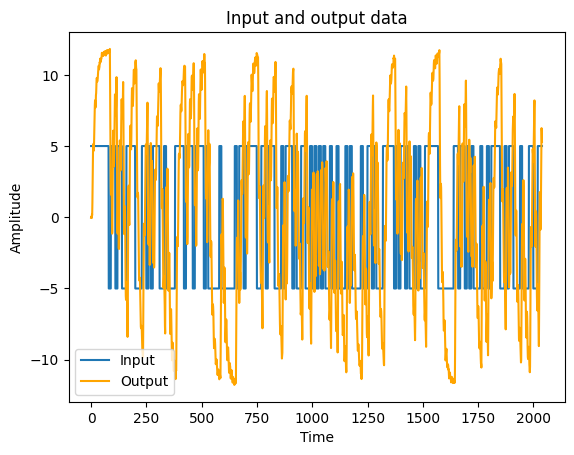

In [4]:
plt.plot(range(0,u_train.shape[0]), u_train,label='Input')
plt.plot(range(0,u_train.shape[0]), output_train, label='Output',color='orange')
plt.legend()
plt.title('Input and output data')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

## Functions definitions

### Function $\phi$ 

In [ ]:
# phi function
def phi(p,n,d,m,u_inputs,y_outputs):
    """u_inputs: input data
       y_outputs: output data
       p: time
       phi(p) = [y(p-1),y(p-2),...,y(p-n),u(p-d),u(p-d-1),...,u(p-d-m)]
    """

    # first part of the vector for y(k-1) to y(k-n)
    first_part = np.zeros(n)
    for n in range(1,n+1):
        first_part[n-1] = y_outputs[p-n]

    # second part of the vector for u(k-d) to u(k-d-m)
    second_part = np.zeros(d+m)
    for m in range(d,d+m+1):
        second_part[m-1] = u_inputs[p-m]
   
    # concatenation of the two parts
    phi = np.concatenate((first_part,second_part))
    print('Size of phi:', phi.shape, "the size of n+d+m is :", n+d+m)
    return phi


### Function $y(k)$

In [ ]:
def y(k,n,d,m,u_inputs,y_outputs,theta, noise) :
    """
    y(k) = phi(k)*theta + noise
    """
    return np.multiply(phi(k,n,d,m,u_inputs,y_outputs),theta) + noise

## Creation of the vectors

In [7]:
# time
k = range(0,u_train.shape[0])

# n 
n_seq = np.arange(0, 10,0.1)

#d 
d_seq = np.arange(0, 10,0.1)

#m 
m_seq = np.arange(0, 10,0.1)

In [ ]:
for n in n_seq :
    for d in d_seq :
        for m in m_seq :
            p = np.max(n,d+m)
            
        
